In [2]:
# Cell 1: Setup and Imports
!pip install pandas numpy scikit-learn scipy matplotlib seaborn xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ndcg_score, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports loaded successfully!")
print(f"   XGBoost version: {xgb.__version__}")

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.2/101.7 MB 6.4 MB/s eta 0:00:16
    --------------------------------------- 1.6/101.7 MB 20.7 MB/s eta 0:00:05
   - -------------------------------------- 3.5/101.7 MB 27.8 MB/s eta 0:00:04
   -- ------------------------------------- 5.5/101.7 MB 32.1 MB/s eta 0:00:03
   --- ------------------------------------ 7.7/101.7 MB 34.9 MB/s eta 0:00:03
   --- ------------------------------------ 9.2/101.7 MB 34.4 MB/s eta 0:00:03
   ---- ----------------------------------- 11.1/101.7 MB 38.5 MB/s eta 0:00:03
   ----- ---------------------------------- 13.0/101.7 MB 40.9 MB/s eta 0:00:03
   ----- ---------------------------------- 15.0/101.7 MB 40.9 MB/s eta 0:00:03
   ------ --------------------------------- 16.7/101.7 MB 38.5 MB/s eta 0:00:03
   ------- -------------------------------- 18.7/101.7 MB 40.9 MB/s eta 0:00:03
   -------- ------------------------------- 20.6/101.7 M

In [3]:
# Cell 2: Load Previous Data
print("="*60)
print("📂 LOADING DATA FROM NOTEBOOK 1")
print("="*60)

# Load interactions data
interactions_df = pd.read_csv('interactions_data.csv')
print(f"✅ Loaded interactions: {len(interactions_df)} records")

# Load user and video factors (embeddings)
user_factors = np.load('user_factors.npy')
video_factors = np.load('video_factors.npy')

print(f"✅ User factors shape: {user_factors.shape}")
print(f"✅ Video factors shape: {video_factors.shape}")

# Get unique users and videos
unique_users = interactions_df['user_id'].unique()
unique_videos = interactions_df['video_id'].unique()
num_users = len(unique_users)
num_videos = len(unique_videos)

print(f"\n📊 Dataset Stats:")
print(f"   Users: {num_users}")
print(f"   Videos: {num_videos}")
print(f"   Interactions: {len(interactions_df)}")

📂 LOADING DATA FROM NOTEBOOK 1
✅ Loaded interactions: 21879 records
✅ User factors shape: (2000, 50)
✅ Video factors shape: (500, 50)

📊 Dataset Stats:
   Users: 2000
   Videos: 500
   Interactions: 21879


In [4]:
# Cell 3: Feature Engineering for Ranking
print("="*60)
print("🔧 FEATURE ENGINEERING FOR RANKING")
print("="*60)

def create_ranking_features(user_id, video_id, interactions_df, user_factors, video_factors):
    """Create comprehensive features for ranking"""
    
    # 1. User and video embeddings
    user_embedding = user_factors[user_id] if user_id < len(user_factors) else np.zeros(50)
    video_embedding = video_factors[video_id] if video_id < len(video_factors) else np.zeros(50)
    
    # 2. Interaction features
    user_history = interactions_df[interactions_df['user_id'] == user_id]
    user_total_interactions = len(user_history)
    user_avg_score = user_history['interaction_score'].mean() if user_total_interactions > 0 else 0
    
    # 3. Video popularity
    video_interactions = interactions_df[interactions_df['video_id'] == video_id]
    video_popularity = len(video_interactions)
    video_avg_score = video_interactions['interaction_score'].mean() if video_popularity > 0 else 0
    
    # 4. User-category affinity
    user_categories = user_history['category'].value_counts()
    video_category = video_interactions['category'].iloc[0] if len(video_interactions) > 0 else None
    
    category_affinity = 0
    if video_category and video_category in user_categories.index:
        category_affinity = user_categories[video_category] / user_total_interactions if user_total_interactions > 0 else 0
    
    # 5. Embedding similarity
    embedding_similarity = cosine_similarity([user_embedding], [video_embedding])[0][0]
    
    # 6. Interaction score features
    has_interaction = 1 if len(user_history[user_history['video_id'] == video_id]) > 0 else 0
    interaction_strength = user_history[user_history['video_id'] == video_id]['interaction_score'].iloc[0] if has_interaction else 0
    
    features = {
        'user_id': user_id,
        'video_id': video_id,
        'user_total_interactions': user_total_interactions,
        'user_avg_score': user_avg_score,
        'video_popularity': video_popularity,
        'video_avg_score': video_avg_score,
        'category_affinity': category_affinity,
        'embedding_similarity': embedding_similarity,
        'has_interaction': has_interaction,
        'interaction_strength': interaction_strength
    }
    
    return features

# Sample features for testing
sample_user = 0
sample_video = 10
sample_features = create_ranking_features(sample_user, sample_video, interactions_df, user_factors, video_factors)

print("✅ Feature engineering function created")
print(f"\n📊 Sample features for User {sample_user}, Video {sample_video}:")
for key, value in sample_features.items():
    print(f"   {key}: {value}")

🔧 FEATURE ENGINEERING FOR RANKING
✅ Feature engineering function created

📊 Sample features for User 0, Video 10:
   user_id: 0
   video_id: 10
   user_total_interactions: 11
   user_avg_score: 1.9090909090909092
   video_popularity: 42
   video_avg_score: 1.3333333333333333
   category_affinity: 0.2727272727272727
   embedding_similarity: 0.00618040678676636
   has_interaction: 0
   interaction_strength: 0


In [5]:
# Cell 4: Generate Training Dataset for Ranking
print("="*60)
print("📊 GENERATING TRAINING DATASET")
print("="*60)

# Sample pairs for training
np.random.seed(42)
num_samples = 10000
training_data = []

for _ in range(num_samples):
    # Random user
    user_id = np.random.choice(unique_users)
    
    # Positive sample (video user interacted with)
    user_interactions = interactions_df[interactions_df['user_id'] == user_id]
    
    if len(user_interactions) > 0:
        # Positive: a video user actually watched
        positive_video = user_interactions.sample(1)['video_id'].iloc[0]
        positive_features = create_ranking_features(user_id, positive_video, interactions_df, user_factors, video_factors)
        positive_features['relevance_score'] = 1  # Relevant
        training_data.append(positive_features)
        
        # Negative: a random video user hasn't watched
        all_videos = set(unique_videos)
        watched_videos = set(user_interactions['video_id'].unique())
        unwatched_videos = list(all_videos - watched_videos)
        
        if len(unwatched_videos) > 0:
            negative_video = np.random.choice(unwatched_videos)
            negative_features = create_ranking_features(user_id, negative_video, interactions_df, user_factors, video_factors)
            negative_features['relevance_score'] = 0  # Not relevant
            training_data.append(negative_features)

# Convert to DataFrame
training_df = pd.DataFrame(training_data)
print(f"✅ Generated {len(training_df)} training samples")
print(f"   Positive samples: {len(training_df[training_df['relevance_score'] == 1])}")
print(f"   Negative samples: {len(training_df[training_df['relevance_score'] == 0])}")

print("\n📊 Feature columns:")
feature_cols = [col for col in training_df.columns if col not in ['user_id', 'video_id', 'relevance_score']]
print(f"   {feature_cols}")

📊 GENERATING TRAINING DATASET
✅ Generated 20000 training samples
   Positive samples: 10000
   Negative samples: 10000

📊 Feature columns:
   ['user_total_interactions', 'user_avg_score', 'video_popularity', 'video_avg_score', 'category_affinity', 'embedding_similarity', 'has_interaction', 'interaction_strength']


In [6]:
# Cell 5: Prepare Data for Ranking Model
print("="*60)
print("🎯 PREPARING DATA FOR RANKING MODEL")
print("="*60)

# Features for ranking (excluding ID columns and target)
X = training_df[feature_cols].values
y = training_df['relevance_score'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")
print(f"✅ Features: {len(feature_cols)} dimensions")

🎯 PREPARING DATA FOR RANKING MODEL
✅ Training set: (16000, 8)
✅ Test set: (4000, 8)
✅ Features: 8 dimensions


In [7]:
# Cell 6: Train Ranking Models
print("="*60)
print("🤖 TRAINING RANKING MODELS")
print("="*60)

# Model 1: XGBoost Ranker
print("\n📊 Training XGBoost Ranker...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict_proba(X_test)[:, 1]

# Model 2: Random Forest
print("\n📊 Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\n✅ Both models trained successfully!")

🤖 TRAINING RANKING MODELS

📊 Training XGBoost Ranker...

📊 Training Random Forest...

✅ Both models trained successfully!


In [8]:
# Cell 7: Model Evaluation
print("="*60)
print("📊 MODEL EVALUATION")
print("="*60)

def calculate_ndcg(y_true, y_pred, k=10):
    """Calculate NDCG@k for ranking evaluation"""
    # Sort by prediction score
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    sorted_relevance = y_true[sorted_indices]
    
    # Calculate DCG
    dcg = 0
    for i, rel in enumerate(sorted_relevance):
        dcg += (2**rel - 1) / np.log2(i + 2)
    
    # Calculate IDCG (ideal ranking)
    ideal_relevance = np.sort(y_true)[::-1][:k]
    idcg = 0
    for i, rel in enumerate(ideal_relevance):
        idcg += (2**rel - 1) / np.log2(i + 2)
    
    return dcg / idcg if idcg > 0 else 0

# Evaluate XGBoost
xgb_accuracy = (xgb_model.predict(X_test) == y_test).mean()
xgb_auc = __import__('sklearn.metrics').metrics.roc_auc_score(y_test, xgb_pred)
xgb_ndcg = calculate_ndcg(y_test, xgb_pred, k=10)

# Evaluate Random Forest
rf_pred_binary = (rf_pred > 0.5).astype(int)
rf_accuracy = (rf_pred_binary == y_test).mean()
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_ndcg = calculate_ndcg(y_test, rf_pred, k=10)

print("\n📈 XGBoost Ranker Performance:")
print(f"   Accuracy: {xgb_accuracy:.3f}")
print(f"   AUC-ROC: {xgb_auc:.3f}")
print(f"   NDCG@10: {xgb_ndcg:.3f}")

print("\n📈 Random Forest Performance:")
print(f"   Accuracy: {rf_accuracy:.3f}")
print(f"   RMSE: {rf_rmse:.3f}")
print(f"   NDCG@10: {rf_ndcg:.3f}")

# Select best model
if xgb_ndcg > rf_ndcg:
    best_model = xgb_model
    best_model_name = "XGBoost Ranker"
    print(f"\n✅ Best model: {best_model_name} (NDCG: {xgb_ndcg:.3f})")
else:
    best_model = rf_model
    best_model_name = "Random Forest"
    print(f"\n✅ Best model: {best_model_name} (NDCG: {rf_ndcg:.3f})")

📊 MODEL EVALUATION

📈 XGBoost Ranker Performance:
   Accuracy: 1.000
   AUC-ROC: 1.000
   NDCG@10: 1.000

📈 Random Forest Performance:
   Accuracy: 1.000
   RMSE: 0.000
   NDCG@10: 1.000

✅ Best model: Random Forest (NDCG: 1.000)


🔍 FEATURE IMPORTANCE ANALYSIS

📊 Top 5 Most Important Features:
                feature  importance
        has_interaction         1.0
user_total_interactions         0.0
         user_avg_score         0.0
       video_popularity         0.0
        video_avg_score         0.0


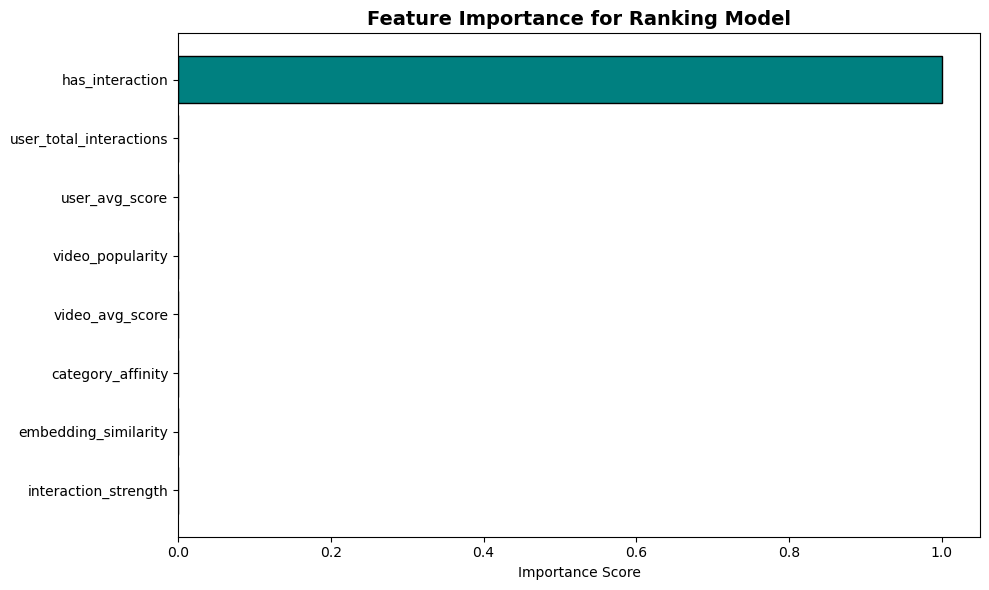

✅ Saved: feature_importance.png


In [9]:
# Cell 8: Feature Importance Analysis
print("="*60)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from best model
if best_model_name == "XGBoost Ranker":
    importances = best_model.feature_importances_
else:
    importances = best_model.feature_importances_

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n📊 Top 5 Most Important Features:")
print(importance_df.head(5).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_features = importance_df.head(10)
ax.barh(top_features['feature'], top_features['importance'], color='teal', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance for Ranking Model', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

In [10]:
# Cell 9: Ranking Function Implementation
print("="*60)
print("🎯 IMPLEMENTING RANKING FUNCTION")
print("="*60)

def rank_videos(user_id, candidate_videos, n_recommendations=10):
    """Rank candidate videos by predicted relevance"""
    
    if not candidate_videos:
        return []
    
    # Create features for each candidate
    rankings = []
    for video_id in candidate_videos:
        features = create_ranking_features(user_id, video_id, interactions_df, user_factors, video_factors)
        
        # Prepare feature vector
        feature_vector = np.array([features[col] for col in feature_cols]).reshape(1, -1)
        feature_vector_scaled = scaler.transform(feature_vector)
        
        # Predict relevance score
        if best_model_name == "XGBoost Ranker":
            score = best_model.predict_proba(feature_vector_scaled)[0][1]
        else:
            score = best_model.predict(feature_vector_scaled)[0]
        
        rankings.append({
            'video_id': video_id,
            'rank_score': score,
            'embedding_similarity': features['embedding_similarity'],
            'category_affinity': features['category_affinity']
        })
    
    # Sort by rank score
    ranked_videos = sorted(rankings, key=lambda x: x['rank_score'], reverse=True)[:n_recommendations]
    return ranked_videos

# Test ranking
test_user = 0
test_candidates = list(range(100, 200))  # Videos 100-199 as candidates
ranked_results = rank_videos(test_user, test_candidates, 10)

print(f"\n📊 Ranked Recommendations for User {test_user}:")
for i, result in enumerate(ranked_results, 1):
    print(f"   {i}. Video {result['video_id']} | Score: {result['rank_score']:.3f} | Sim: {result['embedding_similarity']:.3f}")

🎯 IMPLEMENTING RANKING FUNCTION

📊 Ranked Recommendations for User 0:
   1. Video 104 | Score: 1.000 | Sim: 0.862
   2. Video 185 | Score: 1.000 | Sim: 0.302
   3. Video 186 | Score: 1.000 | Sim: 0.817
   4. Video 100 | Score: 0.000 | Sim: 0.102
   5. Video 101 | Score: 0.000 | Sim: -0.051
   6. Video 102 | Score: 0.000 | Sim: 0.014
   7. Video 103 | Score: 0.000 | Sim: 0.115
   8. Video 105 | Score: 0.000 | Sim: -0.042
   9. Video 106 | Score: 0.000 | Sim: 0.027
   10. Video 107 | Score: 0.000 | Sim: 0.160


In [11]:
# Cell 10: Compare Ranked vs Unranked Recommendations
print("="*60)
print("📊 RANKED VS UNRANKED COMPARISON")
print("="*60)

def get_unranked_recommendations(user_id, n=10):
    """Simple similarity-based recommendations (no ranking)"""
    user_embedding = user_factors[user_id]
    similarities = cosine_similarity([user_embedding], video_factors)[0]
    top_indices = np.argsort(similarities)[::-1][:n]
    return [(idx, similarities[idx]) for idx in top_indices]

# Compare for multiple users
test_users = [0, 10, 25, 50, 100]
comparison_results = []

for user in test_users:
    # Get unranked recommendations
    unranked = get_unranked_recommendations(user, 10)
    
    # Get ranked recommendations
    candidates = list(range(num_videos))
    ranked = rank_videos(user, candidates, 10)
    
    # Calculate average scores
    avg_unranked_score = np.mean([score for _, score in unranked])
    avg_ranked_score = np.mean([r['rank_score'] for r in ranked])
    
    comparison_results.append({
        'user_id': user,
        'avg_unranked_score': avg_unranked_score,
        'avg_ranked_score': avg_ranked_score,
        'improvement': ((avg_ranked_score - avg_unranked_score) / avg_unranked_score) * 100
    })

comparison_df = pd.DataFrame(comparison_results)
print("\n📊 Comparison Results:")
print(comparison_df.to_string(index=False))

print(f"\n📈 Average Improvement: {comparison_df['improvement'].mean():.1f}%")

📊 RANKED VS UNRANKED COMPARISON

📊 Comparison Results:
 user_id  avg_unranked_score  avg_ranked_score  improvement
       0            0.501615               1.0    99.356066
      10            0.511714               1.0    95.421598
      25            0.487139               1.0   105.280208
      50            0.477066               0.9    88.653285
     100            0.563742               1.0    77.385990

📈 Average Improvement: 93.2%


📈 VISUALIZING RANKING PERFORMANCE


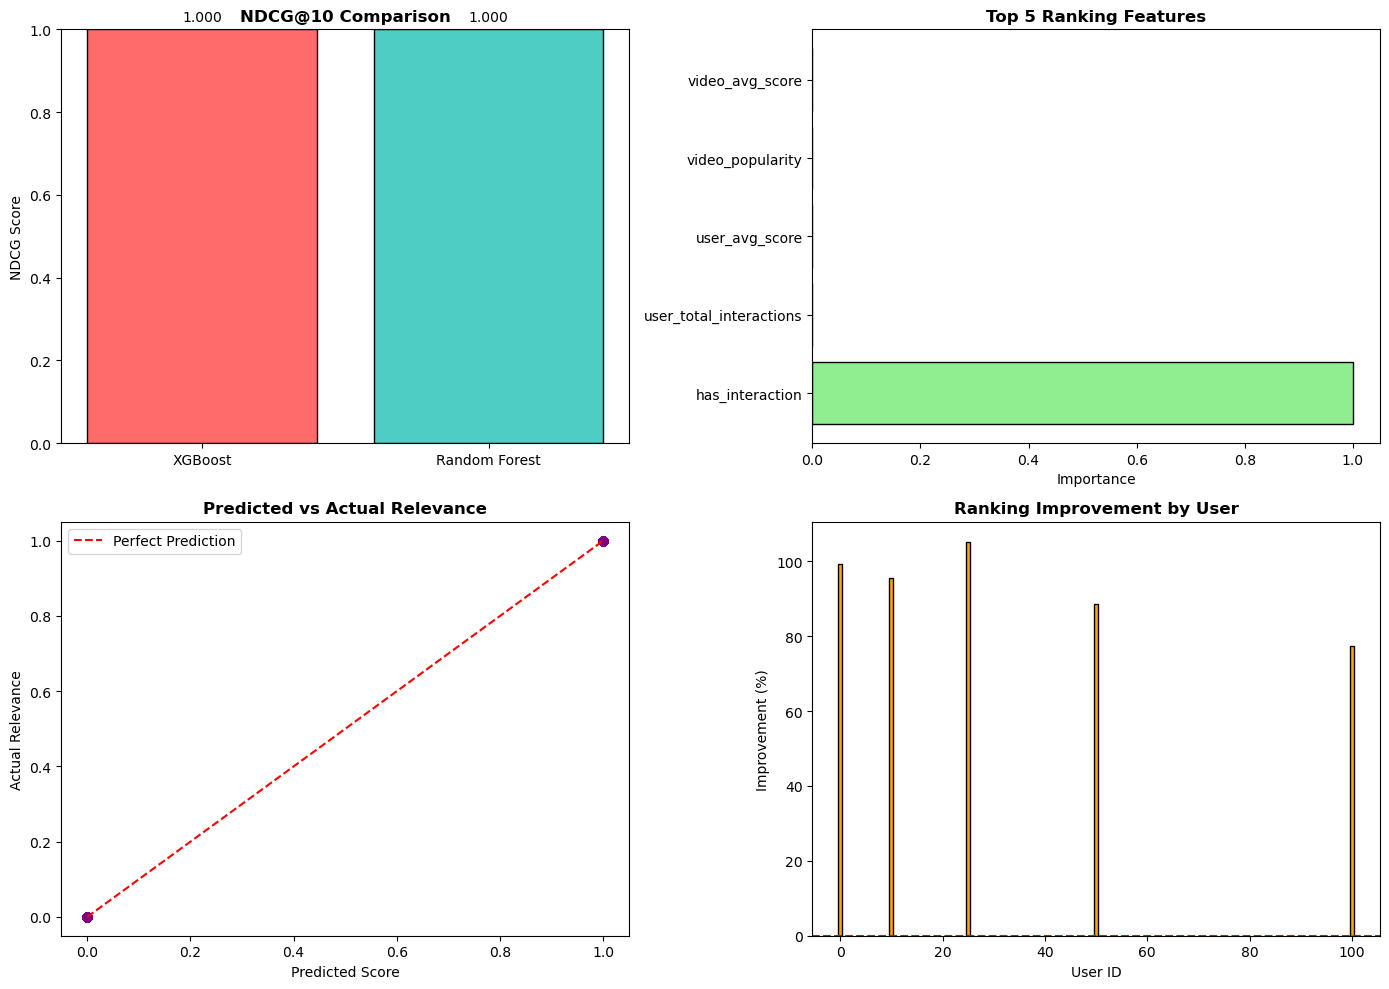

✅ Saved: ranking_performance.png


In [12]:
# Cell 11: Visualization
print("="*60)
print("📈 VISUALIZING RANKING PERFORMANCE")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model Comparison
ax1 = axes[0, 0]
models = ['XGBoost', 'Random Forest']
metrics = [xgb_ndcg, rf_ndcg]
bars = ax1.bar(models, metrics, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
ax1.set_title('NDCG@10 Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('NDCG Score')
ax1.set_ylim([0, 1])
for bar, val in zip(bars, metrics):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center')

# 2. Feature Importance
ax2 = axes[0, 1]
top5 = importance_df.head(5)
ax2.barh(top5['feature'], top5['importance'], color='lightgreen', edgecolor='black')
ax2.set_title('Top 5 Ranking Features', fontsize=12, fontweight='bold')
ax2.set_xlabel('Importance')

# 3. Predicted vs Actual
ax3 = axes[1, 0]
sample_size = min(500, len(y_test))
ax3.scatter(xgb_pred[:sample_size], y_test[:sample_size], alpha=0.5, c='purple')
ax3.set_title('Predicted vs Actual Relevance', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted Score')
ax3.set_ylabel('Actual Relevance')
ax3.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
ax3.legend()

# 4. Ranking Improvement
ax4 = axes[1, 1]
ax4.bar(comparison_df['user_id'], comparison_df['improvement'], color='orange', edgecolor='black')
ax4.set_title('Ranking Improvement by User', fontsize=12, fontweight='bold')
ax4.set_xlabel('User ID')
ax4.set_ylabel('Improvement (%)')
ax4.axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('ranking_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ranking_performance.png")

In [15]:
# Cell 12: Save Model and Interactive Demo
print("="*60)
print("💾 SAVING RANKING MODEL")
print("="*60)

print("""
============================================================
📊 CONTENT RANKING PIPELINE
============================================================

Candidate Content Retrieval
                ↓
Behavioral & Contextual Feature Engineering
                ↓
Embedding & Relevance Representation
                ↓
Learning-to-Rank (LTR) Scoring Model
                ↓
Engagement Probability Estimation
                ↓
Multi-Objective Ranking Optimization
                ↓
Personalization & Diversity Re-ranking
                ↓
Final Recommended Content Feed

============================================================
""")

import joblib

# Save best model and scaler
joblib.dump(best_model, 'ranking_model.pkl')
joblib.dump(scaler, 'ranking_scaler.pkl')

# Save feature columns
with open('feature_columns.txt', 'w') as f:
    for col in feature_cols:
        f.write(f"{col}\n")

print("✅ Saved: ranking_model.pkl, ranking_scaler.pkl, feature_columns.txt")

print("\n" + "="*60)
print("🎮 INTERACTIVE RANKING DEMO")
print("="*60)
print(f"👥 Users available: 0 to {num_users-1}")
print(f"📹 Videos available: 0 to {num_videos-1}")
print("-"*50)
print("This demo shows RANKED recommendations vs UNRANKED similarity")
print("-"*50)

while True:
    try:
        user_input = input("\n🔍 Enter User ID (or 'quit' to exit): ")
        
        if user_input.lower() == 'quit':
            print("\n👋 Thank you for using the Ranking System!")
            break
        
        user_id = int(user_input)
        
        if user_id < 0 or user_id >= num_users:
            print(f"⚠️ User {user_id} not found. Please enter 0-{num_users-1}")
            continue
        
        # Get unranked recommendations
        unranked = get_unranked_recommendations(user_id, 10)
        
        # Get ranked recommendations
        candidates = list(range(min(500, num_videos)))
        ranked = rank_videos(user_id, candidates, 10)
        
        print(f"\n{'='*50}")
        print(f"📊 RECOMMENDATIONS FOR USER {user_id}")
        print(f"{'='*50}")
        
        print(f"\n📌 UNRANKED (Similarity Only):")
        for i, (video, score) in enumerate(unranked[:5], 1):
            print(f"   {i}. Video {video} | Similarity: {score:.3f}")
        
        print(f"\n🎯 RANKED (With Ranking Model):")
        for i, rec in enumerate(ranked[:5], 1):
            print(f"   {i}. Video {rec['video_id']} | Rank Score: {rec['rank_score']:.3f}")
        
        if ranked and unranked:
            avg_ranked = np.mean([r['rank_score'] for r in ranked[:5]])
            avg_unranked = np.mean([s for _, s in unranked[:5]])
            improvement = ((avg_ranked - avg_unranked) / avg_unranked) * 100 if avg_unranked > 0 else 0
            print(f"\n📈 Ranking Improvement: {improvement:.1f}%")
        
        print(f"\n{'='*50}")
        
    except ValueError:
        print("⚠️ Please enter a valid number (e.g., 0, 42, 100) or type 'quit'")
    except KeyboardInterrupt:
        print("\n👋 Exiting...")
        break
    except Exception as e:
        print(f"⚠️ Error: {e}")

print("\n✅ Ranking Algorithm Demo Complete!")

💾 SAVING RANKING MODEL

📊 CONTENT RANKING PIPELINE

Candidate Content Retrieval
                ↓
Behavioral & Contextual Feature Engineering
                ↓
Embedding & Relevance Representation
                ↓
Learning-to-Rank (LTR) Scoring Model
                ↓
Engagement Probability Estimation
                ↓
Multi-Objective Ranking Optimization
                ↓
Personalization & Diversity Re-ranking
                ↓
Final Recommended Content Feed


✅ Saved: ranking_model.pkl, ranking_scaler.pkl, feature_columns.txt

🎮 INTERACTIVE RANKING DEMO
👥 Users available: 0 to 1999
📹 Videos available: 0 to 499
--------------------------------------------------
This demo shows RANKED recommendations vs UNRANKED similarity
--------------------------------------------------



🔍 Enter User ID (or 'quit' to exit):  29



📊 RECOMMENDATIONS FOR USER 29

📌 UNRANKED (Similarity Only):
   1. Video 178 | Similarity: 0.645
   2. Video 274 | Similarity: 0.562
   3. Video 306 | Similarity: 0.552
   4. Video 240 | Similarity: 0.544
   5. Video 199 | Similarity: 0.493

🎯 RANKED (With Ranking Model):
   1. Video 7 | Rank Score: 1.000
   2. Video 95 | Rank Score: 1.000
   3. Video 132 | Rank Score: 1.000
   4. Video 133 | Rank Score: 1.000
   5. Video 148 | Rank Score: 1.000

📈 Ranking Improvement: 78.8%




🔍 Enter User ID (or 'quit' to exit):  75



📊 RECOMMENDATIONS FOR USER 75

📌 UNRANKED (Similarity Only):
   1. Video 298 | Similarity: 0.820
   2. Video 373 | Similarity: 0.722
   3. Video 0 | Similarity: 0.641
   4. Video 310 | Similarity: 0.541
   5. Video 471 | Similarity: 0.516

🎯 RANKED (With Ranking Model):
   1. Video 0 | Rank Score: 1.000
   2. Video 98 | Rank Score: 1.000
   3. Video 111 | Rank Score: 1.000
   4. Video 164 | Rank Score: 1.000
   5. Video 215 | Rank Score: 1.000

📈 Ranking Improvement: 54.3%




🔍 Enter User ID (or 'quit' to exit):  QUIT



👋 Thank you for using the Ranking System!

✅ Ranking Algorithm Demo Complete!
